<a href="https://colab.research.google.com/github/margaretha-ririn/Inventory-Management/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
from google.colab import drive
drive.mount('/content/drive')
data_path = '/content/drive/MyDrive/dataset_animals'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
import os

train_dir = os.path.join(data_path, 'train')
val_dir = os.path.join(data_path, 'val')

print("Train folder:", os.listdir(train_dir))
print("Val folder:", os.listdir(val_dir))

Train folder: ['dog', 'wild', 'cat']
Val folder: ['cat', 'dog', 'wild']


In [29]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [30]:
# =============================================
# CELL 2 - Load Dataset dari Google Drive
# =============================================

image_path = []
labels = []

# Loop semua split (train, val) dan semua kelas
for split in os.listdir(data_path):
    split_path = os.path.join(data_path, split)
    if not os.path.isdir(split_path):
        continue
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if not os.path.isdir(label_path):
            continue
        for image in os.listdir(label_path)[:100]:
            image_path.append(os.path.join(split_path, label, image))
            labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])
print("Total data:", len(data_df))
print("Kelas:", data_df["labels"].unique())
data_df.head()

Total data: 600
Kelas: ['dog' 'wild' 'cat']


,image_path,labels
0,/content/drive/MyDrive/dataset_animals/train/d...,dog
1,/content/drive/MyDrive/dataset_animals/train/d...,dog
2,/content/drive/MyDrive/dataset_animals/train/d...,dog
3,/content/drive/MyDrive/dataset_animals/train/d...,dog
4,/content/drive/MyDrive/dataset_animals/train/d...,dog


In [31]:
# =============================================
# CELL 3 - Split Data 70 / 15 / 15
# =============================================
train = data_df.sample(frac=0.7, random_state=42)
temp  = data_df.drop(train.index)
val   = temp.sample(frac=0.5, random_state=42)
test  = temp.drop(val.index)

print("Train:", train.shape)
print("Val  :", val.shape)
print("Test :", test.shape)

Train: (420, 2)
Val  : (90, 2)
Test : (90, 2)


In [60]:
# =============================================
# CELL 4 - Transform dengan Augmentasi
# (PERBAIKAN 1: tambah augmentasi di train)
# =============================================
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Val & test TIDAK diaugmentasi, hanya resize & normalize
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float),
    transforms.Normalize(mean=[0.5,0.5,0.5],
                         std=[0.5,0.5,0.5])
])

In [61]:
# =============================================
# CELL 5 - Dataset & DataLoader
# =============================================
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.labels = torch.tensor(
            label_encoder.transform(dataframe['labels'])
        ).to(device)

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label    = self.labels[idx]
        image    = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image).to(device)
        return image, label

BATCH_SIZE = 32   # naikkan dari 16 → lebih stabil

train_dataset = CustomImageDataset(train, transform=train_transform)
val_dataset   = CustomImageDataset(val,   transform=val_test_transform)
test_dataset  = CustomImageDataset(test,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

In [62]:
# =============================================
# CELL 6 - Arsitektur Model + Dropout
# (PERBAIKAN 2: tambah Dropout & BatchNorm)
# =============================================
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        self.pooling = nn.MaxPool2d(2, 2)
        self.relu    = nn.ReLU()

        self.flatten = nn.Flatten()

        self.dropout = nn.Dropout(0.5)       # PERBAIKAN: Dropout 50%

        self.linear  = nn.Linear(128*16*16, 256)
        self.output  = nn.Linear(256, len(data_df['labels'].unique()))

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pooling(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pooling(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pooling(x)

        x = self.flatten(x)
        x = self.dropout(x)                  # Dropout sebelum FC layer
        x = self.relu(self.linear(x))
        x = self.dropout(x)                  # Dropout ke-2
        x = self.output(x)

        return x

model = Net().to(device)
print(model)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout): Dropout(p=0.5, inplace=False)
  (linear): Linear(in_features=32768, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=3, bias=True)
)


In [63]:
# =============================================
# CELL 7 - Training dengan EarlyStopping
# (PERBAIKAN 3: EarlyStopping + LR scheduler)
# =============================================
LR     = 8e-5
EPOCHS = 40   # banyak, tapi EarlyStopping yang hentikan

criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)  # weight decay = L2 reg

# Turunkan LR otomatis kalau val_loss stagnan
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

# --- EarlyStopping manual ---
best_val_loss   = float('inf')
patience        = 7
patience_counter = 0
best_model_state = None
# ----------------------------

total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot  = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    # ---- TRAIN ----
    model.train()
    total_acc_train  = 0
    total_loss_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs    = model(inputs)
        train_loss = criterion(outputs, labels)
        train_loss.backward()
        optimizer.step()

        total_loss_train += train_loss.item()
        total_acc_train  += (torch.argmax(outputs, axis=1) == labels).sum().item()

    # ---- VALIDASI ----
    model.eval()
    total_loss_val = 0
    total_acc_val  = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs  = model(inputs)
            val_loss = criterion(outputs, labels)
            total_loss_val += val_loss.item()
            total_acc_val  += (torch.argmax(outputs, axis=1) == labels).sum().item()

    # Hitung rata-rata per epoch
    avg_train_loss = round(total_loss_train / len(train_loader), 4)
    avg_val_loss   = round(total_loss_val   / len(val_loader),   4)
    avg_train_acc  = round((total_acc_train / len(train_dataset)) * 100, 4)
    avg_val_acc    = round((total_acc_val   / len(val_dataset))   * 100, 4)

    total_loss_train_plot.append(avg_train_loss)
    total_loss_validation_plot.append(avg_val_loss)
    total_acc_train_plot.append(avg_train_acc)
    total_acc_validation_plot.append(avg_val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss} Acc: {avg_train_acc}% | "
          f"Val Loss: {avg_val_loss} Acc: {avg_val_acc}%")

    # Update scheduler
    scheduler.step(avg_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"  → Current LR: {current_lr}")

    # Cek EarlyStopping
    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        print(f"  → Val loss membaik, model disimpan.")
    else:
        patience_counter += 1
        print(f"  → Tidak membaik ({patience_counter}/{patience})")
        if patience_counter >= patience:
            print(f"\nEarlyStopping! Berhenti di epoch {epoch+1}.")
            break

# Load model terbaik
model.load_state_dict(best_model_state)
print("\nModel terbaik berhasil di-load!")

Epoch 1/40 | Train Loss: 1.2111 Acc: 43.5714% | Val Loss: 1.0601 Acc: 58.8889%
  → Current LR: 8e-05
  → Val loss membaik, model disimpan.
Epoch 2/40 | Train Loss: 0.8492 Acc: 65.2381% | Val Loss: 0.93 Acc: 65.5556%
  → Current LR: 8e-05
  → Val loss membaik, model disimpan.
Epoch 3/40 | Train Loss: 0.7466 Acc: 64.5238% | Val Loss: 0.6841 Acc: 73.3333%
  → Current LR: 8e-05
  → Val loss membaik, model disimpan.
Epoch 4/40 | Train Loss: 0.5871 Acc: 74.2857% | Val Loss: 0.5256 Acc: 80.0%
  → Current LR: 8e-05
  → Val loss membaik, model disimpan.
Epoch 5/40 | Train Loss: 0.5689 Acc: 75.4762% | Val Loss: 0.4367 Acc: 84.4444%
  → Current LR: 8e-05
  → Val loss membaik, model disimpan.
Epoch 6/40 | Train Loss: 0.5076 Acc: 79.5238% | Val Loss: 0.4264 Acc: 86.6667%
  → Current LR: 8e-05
  → Val loss membaik, model disimpan.
Epoch 7/40 | Train Loss: 0.455 Acc: 80.9524% | Val Loss: 0.3703 Acc: 88.8889%
  → Current LR: 8e-05
  → Val loss membaik, model disimpan.
Epoch 8/40 | Train Loss: 0.4672 A

In [64]:
# =============================================
# CELL 8 - Evaluasi di Test Set
# =============================================
model.eval()
total_loss_test = 0
total_acc_test  = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        predictions = model(inputs)
        acc         = (torch.argmax(predictions, axis=1) == labels).sum().item()
        total_acc_test  += acc
        total_loss_test += criterion(predictions, labels).item()

print(f"Test Accuracy : {round((total_acc_test/len(test_dataset))*100, 4)}%")
print(f"Test Loss     : {round(total_loss_test/len(test_loader), 4)}")

Test Accuracy : 87.7778%
Test Loss     : 0.3202


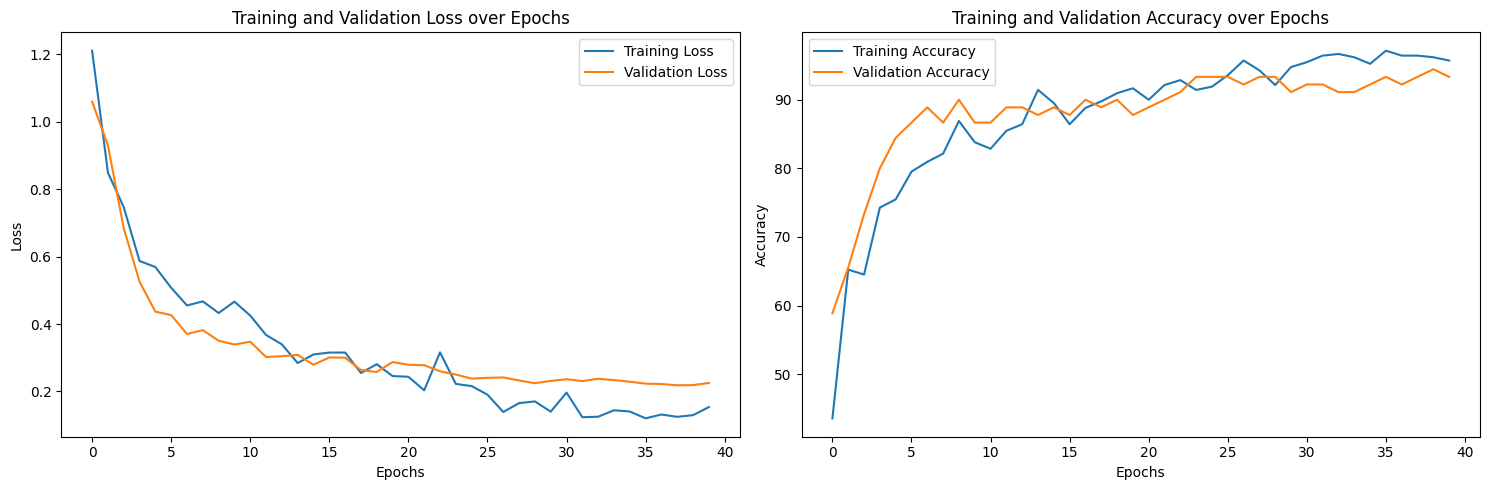

In [65]:
# =============================================
# CELL 9 - Plot Grafik
# =============================================
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.tight_layout()
plt.show()

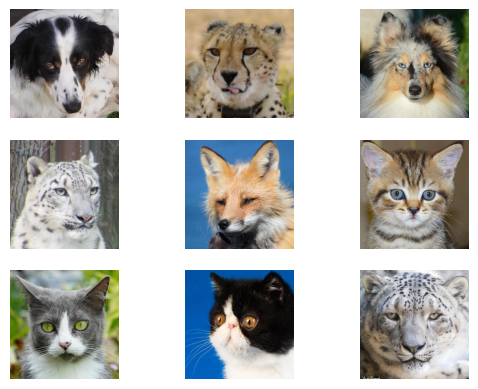

In [66]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [68]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [69]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [70]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding= 1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding= 1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding= 1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*16*16), 128)

    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [71]:
model = Net().to(device)

In [72]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [73]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [74]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/10,
            Train Loss: 0.0274 Train Accuracy 49.7619
            Validation Loss 0.0061 Validation Accuracy 46.6667
        
Epoch 2/10,
            Train Loss: 0.0236 Train Accuracy 60.0
            Validation Loss 0.0048 Validation Accuracy 63.3333
        
Epoch 3/10,
            Train Loss: 0.0193 Train Accuracy 69.5238
            Validation Loss 0.004 Validation Accuracy 73.3333
        
Epoch 4/10,
            Train Loss: 0.0165 Train Accuracy 76.6667
            Validation Loss 0.004 Validation Accuracy 68.8889
        
Epoch 5/10,
            Train Loss: 0.0171 Train Accuracy 75.0
            Validation Loss 0.0039 Validation Accuracy 74.4444
        
Epoch 6/10,
            Train Loss: 0.0133 Train Accuracy 81.1905
            Validation Loss 0.0029 Validation Accuracy 77.7778
        
Epoch 7/10,
            Train Loss: 0.0124 Train Accuracy 83.0952
            Validation Loss 0.0028 Validation Accuracy 82.2222
        
Epoch 8/10,
            Train Loss: 0.0127

In [75]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")


Accuracy Score is: 83.3333 and Loss is 0.0028


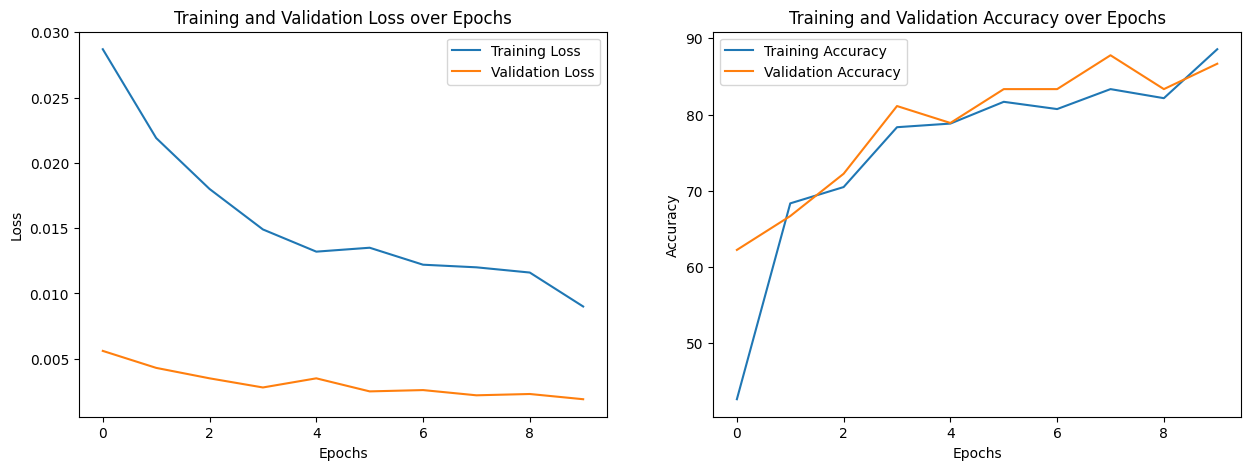

In [50]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [76]:
def predict_image(image_path):
    image = Image.open(image_path).convert('RGB')
    image = val_test_transform(image).to(device)
    model.eval()
    with torch.no_grad():
        output = model(image.unsqueeze(0))
    output = torch.argmax(output, axis=1).item()
    return label_encoder.inverse_transform([output])
